<a href="https://colab.research.google.com/github/avocado-planet/01-ReAct-Agent-Sample/blob/main/ReAct_Agent_Sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q langchain-core langchain-community langchain-openai langgraph langsmith google-search-results

In [ ]:
"""
==============================================================================
【新式】LangGraph ReAct Agent（tool calling 方式）
==============================================================================

■ 方式の特徴:
  - LangGraph の create_react_agent を使用（第2世代）
  - ツール情報は OpenAI の function calling API で LLM に渡す
  - LLM は構造化データ（tool_call）でツール呼び出しを返す
  - テキストのパースは不要

■ プロンプトの扱い:
  - prompt= に渡した文字列は「システムメッセージ」として使われるだけ
  - hwchase17/react の {tools}, {tool_names}, {input}, {agent_scratchpad} は
    展開されない（未展開のまま余計なテキストとして渡される）
  - そのため、Hub からの ReAct プロンプト取得は不要
    シンプルなシステムプロンプト文字列を渡すのが正しい使い方

■ 非推奨情報（2026年4月時点）:
  - langgraph.prebuilt.create_react_agent は LangGraph v1 で非推奨
  - 後継: langchain.agents.create_agent（第3世代、ミドルウェア対応）
  - ただし create_agent 自体も v1.1.0 で一時的に消えた報告があり、
    移行先がまだ安定しきっていない状況
  - 学習目的では create_react_agent で問題なし

■ 内部動作（tool calling 方式）:
  LLM に送られるもの:
    1. system メッセージ: prompt= で渡した文字列
    2. tools 定義: OpenAI function calling 形式の JSON Schema
       [{"name": "Search", "description": "...", "parameters": {...}}]
    3. messages: ユーザーの質問 + 過去の会話履歴

  LLM が返すもの:
    - tool_call: {"name": "Search", "args": {"query": "..."}}
    - または最終回答テキスト

■ 必要パッケージ:
  pip install langchain-core langchain-community langchain-openai \
              langgraph langsmith google-search-results

■ 環境変数:
  OPENAI_API_KEY    : OpenAI API キー（必須）
  SERPAPI_API_KEY    : SerpAPI キー（必須）
  LANGSMITH_API_KEY  : LangSmith キー（オプション、トレース用）
  LANGCHAIN_TRACING_V2 : "true" でトレース有効（オプション）
==============================================================================
"""

import os
import sys
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["SERPAPI_API_KEY"] = userdata.get("SERPAPI_API_KEY")


# ---------------------------------------------------------------------------
# 1. 環境変数チェック
#    APIキーが未設定のまま実行すると、途中で不明瞭なエラーが出るため
#    起動時に確認して早期に失敗させる
# ---------------------------------------------------------------------------
required_env_vars = ["OPENAI_API_KEY", "SERPAPI_API_KEY"]
missing = [v for v in required_env_vars if not os.environ.get(v)]
if missing:
    print(f"[ERROR] 以下の環境変数が未設定です: {', '.join(missing)}")
    print("  例: export OPENAI_API_KEY='sk-...'")
    print("  例: export SERPAPI_API_KEY='...'")
    sys.exit(1)

# ---------------------------------------------------------------------------
# 2. ライブラリのインポート
# ---------------------------------------------------------------------------
from langchain.agents import create_agent               # 第3世代エージェント ★
from langchain_core.tools import Tool                    # ツール定義用
from langchain_community.utilities import SerpAPIWrapper  # Google検索ラッパー

print("環境変数、ライブラリimport完了！")

環境変数、ライブラリimport完了！


Model設定完了！
tools設定完了！
prompt設定完了！


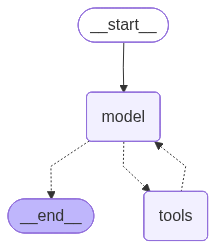

In [ ]:
# ---------------------------------------------------------------------------
# 3. LLM の設定
#    第3世代では model に文字列を直接渡せる（"openai:gpt-4o-mini" 形式）
#    ChatOpenAI インスタンスを渡すことも可能
# ---------------------------------------------------------------------------
# 方法1: 文字列で指定（第3世代の新機能）
MODEL_NAME = "openai:gpt-4o-mini"

# 方法2: ChatOpenAI インスタンスで指定（従来通りも可能）
# from langchain_openai import ChatOpenAI
# model = ChatOpenAI(temperature=0, model="gpt-4o-mini")

print("Model設定完了！")

# ---------------------------------------------------------------------------
# 4. ツール（Tool）の設定
#    エージェントが「行動」として使える外部機能を定義する。
#    ここでは SerpAPI を使った Google 検索を1つだけ設定。
#
#    Tool の各引数:
#    - name        : エージェントがツールを識別するための名前
#    - func        : 実際に呼び出される関数
#    - description : LLM がツールの使い時を判断するための説明文
#                    （この説明が曖昧だとツールが正しく選ばれない）
# ---------------------------------------------------------------------------
search = SerpAPIWrapper()
tools = [
    Tool(
        name="Search",
        func=search.run,
        description=(
            "Useful for answering questions about current events, "
            "recent news, or real-time information that the LLM may not know."
        ),
    )
]

print("tools設定完了！")

# ---------------------------------------------------------------------------
# 5. エージェントの作成
#
#    create_agent() のパラメータ:
#    - model          : LLM（文字列 or ChatModel インスタンス）
#    - tools          : エージェントが使えるツールのリスト
#    - system_prompt  : システムメッセージ（旧 prompt から改名）
#    - middleware      : ミドルウェアのリスト（第3世代の新機能）
#    - checkpointer   : 会話履歴の永続化（オプション）
#    - debug          : True でデバッグ出力（オプション）
#
#    内部で構築されるグラフ:
#
#      [開始] → [LLMノード] →（tool_call が含まれる？）
#                    ↑               |
#                    |          Yes   |   No
#                    |               ↓
#               [ツールノード]   [最終回答]
#
#    ミドルウェアのフック:
#      before_model    → LLM 呼び出し前（ステート変更、ジャンプ等）
#      after_model     → LLM 呼び出し後（ステート変更、ジャンプ等）
#      wrap_model_call → LLM 呼び出し自体をラップ（動的モデル選択等）
#      wrap_tool_call  → ツール呼び出しをラップ（動的ツール等）
# ---------------------------------------------------------------------------
agent_executor = create_agent(
    model=MODEL_NAME,
    tools=tools,
    system_prompt="You are a helpful assistant. Think step by step and use tools when needed.when you got a answer you should check If it is a reasonable answer",
    # middleware=[],   # ← ミドルウェアを追加する場合はここに
    # debug=True,      # ← デバッグ出力を有効にする場合
)

print("prompt設定完了！")

#Agentの構造図を表示する
agent_executor

In [28]:
# ---------------------------------------------------------------------------
# 6. 実行
#    - messages 形式で入力を渡す
#    - invoke() でエージェントを起動
#    - 内部で複数回の LLM呼び出し＋ツール呼び出しを繰り返す
#
#    ★ 実行フロー:
#
#    【ステップ1: 初回】
#      LLM への入力:
#        system: "You are a helpful assistant..."
#        tools:  [{"name":"Search", ...}]    ← API レベルで渡す
#        user:   "2026/4/1ドジャーズの先発投手は？"
#      LLM の出力:
#        → tool_call: Search(query="2026年4月1日 ドジャーズ 先発投手")
#
#    【ステップ2: ツール実行】
#      SerpAPI で検索 → 結果を取得
#
#    【ステップ3: 再度 LLM】
#      LLM への入力:（ステート更新済み）
#        system: "You are a helpful assistant..."
#        user:   "2026/4/1ドジャーズの先発投手は？"
#        ai:     tool_call: Search(...)
#        tool:   "検索結果: ..."            ← Observation に相当
#      LLM の出力:
#        → "2026年4月1日のドジャーズの先発投手は○○です。"（最終回答）
# ---------------------------------------------------------------------------
question = "2026/4/1ドジャーズの先発投手は？"
print(f"\n=== 質問 ===\n{question}")

try:
    result = agent_executor.invoke(
        {"messages": [("user", question)]}
    )

    # 結果の表示
    # result["messages"] にエージェントの全ステップが含まれる:
    #   - human: ユーザーの入力
    #   - ai:    LLM の応答（tool_call or 最終回答）
    #   - tool:  ツールの実行結果
    print("\n=== Agent Response（全ステップ） ===")
    for message in result["messages"]:
        role = message.type

        # ツール呼び出しの場合、呼び出し内容を表示
        if hasattr(message, "tool_calls") and message.tool_calls:
            print(f"[{role}] ツール呼び出し:")
            for tc in message.tool_calls:
                print(f"  → {tc['name']}({tc['args']})")
        elif message.content:
            print(f"[{role}] {message.content}")
        print("---")

    # ---------------------------------------------------------------------------
    # 最終回答の抽出
    # messages の最後の ai メッセージが最終回答
    # ---------------------------------------------------------------------------
    final_answer = result["messages"][-1].content
    print("\n=== 最終回答 ===")
    print(final_answer)

except Exception as e:
    print(f"\n[ERROR] エージェント実行中にエラーが発生しました: {e}")
    print("  - APIキーが正しいか確認してください")
    print("  - ネットワーク接続を確認してください")
    print("  - LangChain 1.0+ がインストールされているか確認してください")
    print("    pip install 'langchain>=1.0' langchain-openai")
    raise



=== 質問 ===
2026/4/1ドジャーズの先発投手は？

=== Agent Response（全ステップ） ===
[human] 2026/4/1ドジャーズの先発投手は？
---
[ai] ツール呼び出し:
  → Search({'__arg1': '2026年4月1日 ドジャーズ 先発投手'})
---
[tool] ['大谷翔平は4月1日のガーディアンズ戦で「1番・投手」として先発し、5回1安打無失点と圧巻の内容を披露。中5日〜6日の間隔での登板が想定されており ...', '2026年ドジャースの先発ローテーション候補 ; 山本由伸, 30試 12勝8敗 防2.49 ; 佐々木朗希, 10試 1勝1敗 防4.46 ; 大谷翔平, 14試 1勝1敗 防2.87 ; スネル, 11試 5勝4敗 防 ...', '勢いは、大谷が2026年の投手デビューを飾った31日（同4月1日）の夜へと引き継がれた。大谷は6回を投げて1安打無失点、6三振、87球。4－1で勝利し、今季初白星 ...', '勝利投手. ドジャース. 大谷 (1勝0敗0S). 敗戦投手. ガーディアンズ. T ... 大谷 翔平, 先発, タナー・バイビー. 指, 大谷 翔平, 1, 中, スティーブン ...', '開幕投手には山本由伸が起用される注目の一戦で、大谷翔平も打線の中心として出場予定。日本人選手が揃う豪華布陣に、世界中のファンの関心が集まっている ...', '既に公表されていた初戦の佐々木朗希、第2戦の大谷翔平に続き、山本由伸が4月1日（同2日）の第3戦で先発すると28日、球団が発表した。 山本は開幕戦で6回2 ...', '大谷翔平、山本由伸、ブレイク・スネル、タイラー・グラスナウ、佐々木朗希によるローテーションを考えれば、先発陣に関しては率直に言って盤石だ。しかし ...', '2026年4月01日 ドジャース対ガーディアンズ MLB試合情報 メンバー成績のページです。MLBの一球速報・日程・結果・順位表・個人成績を掲載中。', 'ドジャース3戦連続で日本人投手が先発、MLB史上初…2失点で黒星の山本由伸「また3人でいい投球を」. 2026/04/02 13:15.']
---
[ai] 2026年4月1日のドジャーズの先発投手は、山本由伸です。彼が開幕戦で先発すると